### Linear Regression using Stochastic Gradient Descent (SDG)

A simple linear regression model using stochastic gradient descent (SGD) to minimize the mean squared error (MSE). The dataset is synthetic, and we will use JAX for efficient computation and automatic differentiation.

### Problem Setup

Given a set of data points $ (x_i, y_i) $, the goal is to learn the parameters $ \theta_0 $ and $ \theta_1 $ such that the model predicts $ y = \theta_0 + \theta_1 x $. We will optimize these parameters using SGD to minimize the MSE loss.


Generate Synthetic data

We will generate synthetic data where  𝑦=1.5𝑥+3 , with some added Gaussian noise. This data will be used to test our linear regression model.

Let us now generate the synthetic dataset using JAX's random number generation functions.

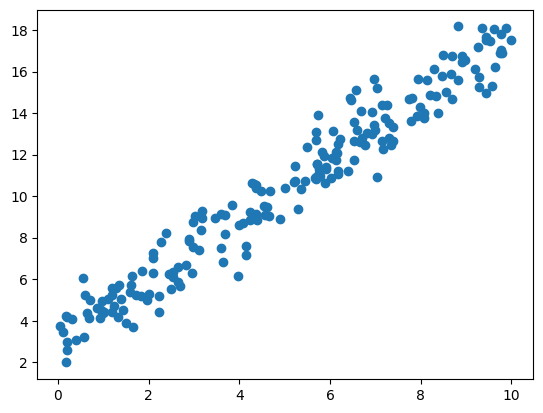

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

N = 200 # number of points
x_data = np.random.uniform(size=(N,)) * 10
y_data = 1.5 * x_data + 3 + np.random.normal(size=(N,)) #true line + noise( epsilon)

# Show a quick preview of generated data
plt.scatter(x_data, y_data)


Split into train and validation datasets

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42
)

# converting to
X_train = jnp.array(X_train)
X_test = jnp.array(X_test)
y_train = jnp.array(y_train)
y_test = jnp.array(y_test)

### Linear Regression Model

The linear regression model is defined as:

$$ y = \theta_0 + \theta_1 x $$

Where $ \theta_0 $ is the intercept and $ \theta_1 $ is the slope. We will define this model and a loss function to optimize it.


In [7]:
# Define the linear regression model
#  if we input the intercept and it's slope
# returns theta0 + theta1*x
# theta might be a matrix, x a vector
@jax.jit
def model(theta, x): # will predict some y
  # SOLUTION-BEGIN
    return theta[0] + theta[1] * x
    # SOLUTION-END
# FILL HERE

### Mean Squared Error (MSE) Loss Function

The loss function we will use is the Mean Squared Error (MSE) between the predicted values and the true values:

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

We will also use JAX's `jit` decorator to optimize this function for faster computation.


In [8]:
# Mean Squared Error loss function
# the function where we want to find the minima
@jax.jit
def mse_loss(theta, x, y):
  # SOLUTION-BEGIN
  y_pred = model(theta, x)
  return jnp.mean((y_pred - y) ** 2)
#loss func = 0 -> model doing perfectly well
# here the order is imp, if x is first then it would be gradient wrt to x
# FILL HERE

### Gradient of the Loss Function

We can compute the gradient of the MSE loss function with respect to the parameters $ \theta_0 $ and $ \theta_1 $ using JAX's automatic differentiation. This will allow us to update the parameters using gradient descent.


In [9]:
# Compute the gradient of the MSE loss function with JAX
# jax.grad function
grad_mse_loss = jax.jit(jax.grad(mse_loss))



### Stochastic Gradient Descent (SGD) Update Step

In Stochastic Gradient Descent (SGD), we update the parameters using the gradient computed on a random mini-batch of the data. This allows for faster convergence compared to using the full dataset at each iteration.

We will define a function to perform a single update step of SGD.


In [18]:
# Stochastic Gradient Descent (SGD) update step, return the updated theta
@jax.jit
# here we are passing the batch, instead of full dataset thus SGD
def sgd_update(theta, x_batch, y_batch, learning_rate):
    # SOLUTION-BEGIN
    grads = grad_mse_loss(theta, x_batch, y_batch)
    return theta - learning_rate * grads
    # SOLUTION-END

### Stochastic Gradient Descent with Mini-batches

We will implement the full Stochastic Gradient Descent (SGD) algorithm, processing the data in mini-batches. At each epoch, we shuffle the data and update the parameters using the mini-batch gradients.

Let's now define the `stochastic_gradient_descent` function.

Fill with the following steps:
- compute and apply a permutation of the training data
- loop on the batches (a slice of size `batch_size` of the training data) and apply the SDG upate


In [19]:
# Stochastic Gradient Descent with mini-batches
def stochastic_gradient_descent(
    theta,
    training_input,
    training_labels,
    validation_input,
    validation_labels,
    learning_rate=0.01,
    epochs=100,
    batch_size=10,
    state=0,
):

    key = jax.random.PRNGKey(state)
    # Iterate over the number of epochs
    # in vanilla gd it was _, no of iterations are the epoch
    for epoch in range(epochs):
        key, subkey = jax.random.split(key)
        # permutation step
        perm = jax.random.permutation(subkey, len(training_input)) #inorder to increase the randomness
        # loop over mini batches
        for i in range(0, len(training_input), batch_size): # i will go from 0 to number of training samples, with step-size as batch_size
          batch_idx = perm[i : i + batch_size] #index from i to batch_size
          x_batch = training_input[batch_idx] # training input at rows batch_indx ( x values of the line)
          y_batch =  training_labels[batch_idx] #training label at rows batch_indx (  y values of the line)
          # input has input values and label has target values
          theta = sgd_update( theta, x_batch, y_batch, learning_rate)
    return theta

### Optimized Parameters

After running the optimization, we will obtain the optimized values of $ \theta_0 $ and $ \theta_1 $. These parameters define the best-fit line for the data.

Let's print the optimized parameters.


In [20]:
# Run the Stochastic Gradient Descent
# Initial guess for theta_0 (intercept) and theta_1 (slope)
theta = jnp.array([0.0, 0.0])
theta_opt = stochastic_gradient_descent(
    theta, X_train, y_train, X_test, y_test, learning_rate=0.01, epochs=100, batch_size=10
)
print(
    f"Optimized parameters: theta = [{theta_opt[0]:.2f}, {theta_opt[1]:.2f}]"
)

Optimized parameters: theta = [3.15, 1.46]


### Visualizing the Results

plot the original data points and the regression line defined by the optimized parameters.


Array(0.75292104, dtype=float32)

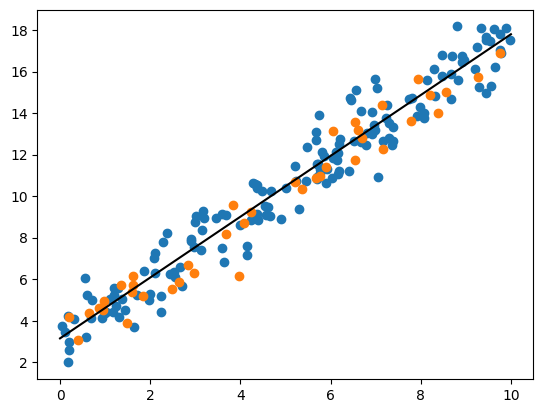

In [23]:
plt.scatter(X_train,y_train)
plt.scatter(X_test,y_test)

x = jnp.linspace(0, 10, 1000)
y = model(theta_opt, x)

plt.plot(x, y, 'k')

mse_loss(theta_opt, X_test, y_test)
